In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np
from sklearn.ensemble import IsolationForest


In [3]:
df = pd.read_csv('./Weather_Data.csv')

In [4]:
df.head()

,Date,City,Temperature (°C),Humidity (%),Wind Speed (km/h),Weather Condition
0,2021-12-07,West Rachel,38.9,75,29.0,Rainy
1,2020-08-30,Port Jill,37.7,67,2.7,Rainy
2,2025-04-19,Priscillafurt,6.8,86,8.6,Cloudy
3,2021-05-01,Jacobmouth,22.1,63,12.2,Sunny
4,2020-05-07,Moranhaven,30.2,39,0.6,Cloudy


In [5]:
# preprocess data
df['Date'] = pd.to_datetime(df['Date'])

# df.set_index("Date",inplace=True)

df = df.sort_values('Date')


In [6]:
print(df.head())

         Date              City  Temperature (°C)  Humidity (%)  \
79 2020-01-16        Amandaview              24.0            68   
50 2020-02-10     North Timothy              -7.5            78   
35 2020-02-29      West Kenneth               5.7            75   
95 2020-02-29         Carrville              29.1            73   
68 2020-03-22  New Michaelburgh              -5.1            77   

    Wind Speed (km/h) Weather Condition  
79               29.3             Snowy  
50               20.0            Cloudy  
35               19.0             Snowy  
95               14.2             Snowy  
68               14.8             Rainy  


In [7]:
df['Temperature (°C)'] = df["Temperature (°C)"].interpolate()
df = df.dropna()

In [8]:
#Basic analysis 

print("max temp",df["Temperature (°C)"].max())
print("min temp",df["Temperature (°C)"].min())
print("mean temp",df["Temperature (°C)"].mean())


max temp 39.7
min temp -9.3
mean temp 16.507


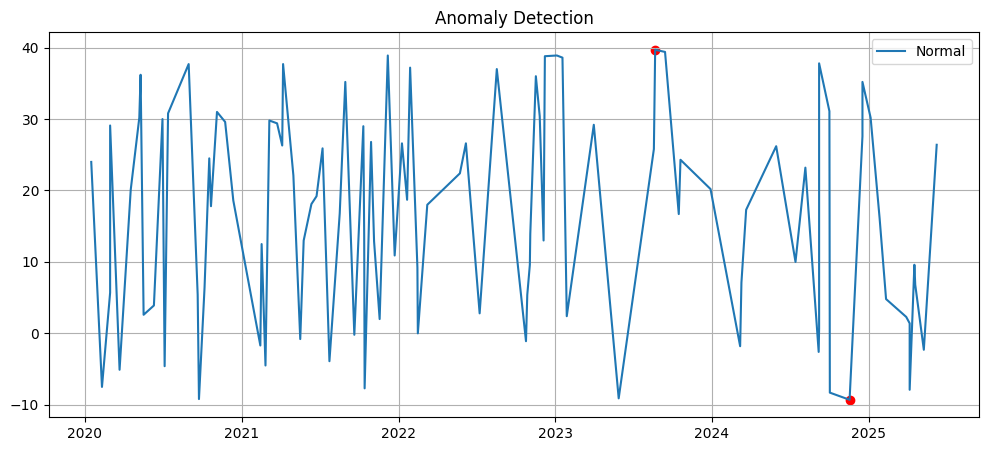

Number of anomalies detected: 2


In [19]:
# 6. ANOMALY DETECTION

model = IsolationForest(contamination=0.02, random_state=42)

pred = model.fit_predict(df['Temperature (°C)'].values.reshape(-1,1))

anomalies = df['Temperature (°C)'][pred == -1]

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Temperature (°C)'], label='Normal')
plt.scatter(df.loc[pred == -1, 'Date'], anomalies, color='red')
plt.title("Anomaly Detection")
plt.legend()
plt.grid(True)
plt.show()

print("Number of anomalies detected:", len(anomalies))

In [10]:
# seasonal pattern (monthly avg)

df["month"] = df["Date"].dt.month
monthly_avg = df.groupby("month")["Temperature (°C)"].mean()

print("monthly average",monthly_avg)

monthly average month
1     25.855556
2      5.288889
3     12.125000
4     15.400000
5     14.050000
6     20.700000
7     10.166667
8     30.771429
9     10.185714
10    13.730769
11    17.344444
12    25.400000
Name: Temperature (°C), dtype: float64


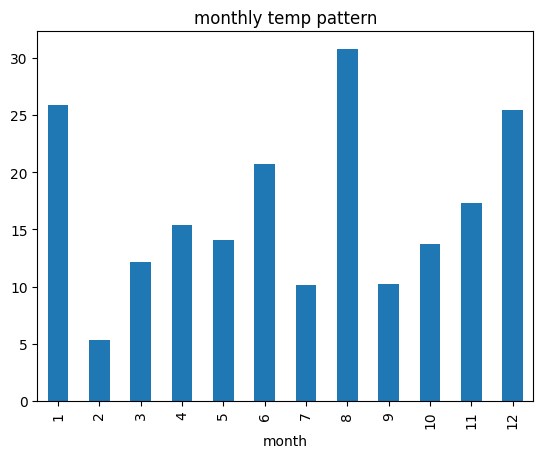

In [11]:
monthly_avg.plot(kind="bar",title="monthly temp pattern")
plt.show()

In [12]:
# forcasting 

df["day_number"] = (df["Date"]-df["Date"].min()).dt.days 

In [13]:
X = df[["day_number"]]
y=df['Temperature (°C)']

In [14]:
X

,day_number
79,0
50,25
35,44
95,44
68,66
...,...
63,1907
73,1918
2,1920
58,1940


In [15]:
y

79    24.0
50    -7.5
35     5.7
95    29.1
68    -5.1
      ... 
63    -7.9
73     9.6
2      6.8
58    -2.3
86    26.4
Name: Temperature (°C), Length: 100, dtype: float64

In [16]:
# train the model 

model = LinearRegression()
model.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
# forcast for the next  7 days
future_days = np.arange(df['day_number'].max()+1,df['day_number'].max()+8)
future_days = future_days.reshape(-1,1)

prediction = model.predict(future_days)

print("the prediction of next 7 days:",prediction)

the prediction of next 7 days: [14.74412013 14.74247629 14.74083246 14.73918863 14.73754479 14.73590096
 14.73425713]


/Users/sushilpandey/Desktop/python-learning/pyLibraries/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


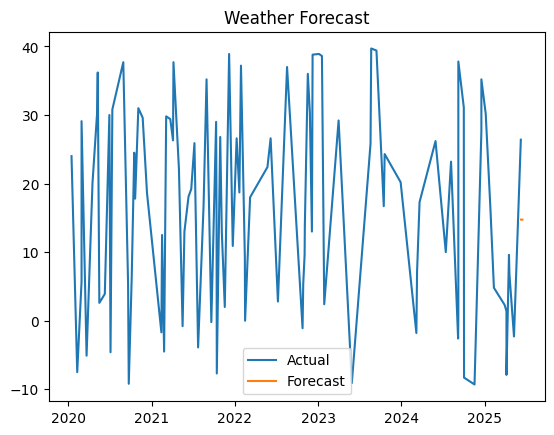

In [ ]:
# STEP 8: Plot forecast
plt.plot(df['Date'], df["Temperature (°C)"], label="Actual")

future_dates = pd.date_range(df['Date'].max(), periods=8)[1:]
plt.plot(future_dates, prediction, label="Forecast")

plt.legend()
plt.title("Weather Forecast")
plt.show()